In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from torch.utils.data import DataLoader

from satx.data import EuroSATDataset, CLASS_NAMES
from satx.visualization import show_RGB

# 1. Standard Split

## 1.1 13 Bands Multispectral Dataset

In [2]:
# Create MS train/test datasets (using standard splits)
ms_train_std = EuroSATDataset(modality='ms', split_type='standard', split='train')
ms_test_std = EuroSATDataset(modality='ms', split_type='standard', split='test')

print(f"Multispectral Train set size: {len(ms_train_std)}")
print(f"Multispectral Test set size: {len(ms_test_std)}")

# Fetch a single sample
ms_img_std, ms_label_std = ms_train_std[0]
print(f"Image shape: {ms_img_std.shape}")
print(f"Label ID: {ms_label_std} ({CLASS_NAMES[ms_label_std]})")

Multispectral Train set size: 16200
Multispectral Test set size: 5400
Image shape: torch.Size([13, 64, 64])
Label ID: 7 (Residential)


In [3]:
# Create DataLoader
train_loader_std = DataLoader(ms_train_std, batch_size=32, shuffle=True, num_workers=2)

# Fetch one batch
for imgs_std, labels_std in train_loader_std:
    print("Batch loaded successfully!")
    print("Batch images shape:", imgs_std.shape)
    print("Batch labels shape:", labels_std.shape)
    break

Batch loaded successfully!
Batch images shape: torch.Size([32, 13, 64, 64])
Batch labels shape: torch.Size([32])


## 1.2. RGB Datasets

In [4]:
# Create RGB train/test datasets (using standard splits)
rgb_train_std = EuroSATDataset(modality='rgb', split_type='standard', split='train')
rgb_test_std = EuroSATDataset(modality='rgb', split_type='standard', split='test')

print(f"RGB Train set size: {len(rgb_train_std)}")
print(f"RGB Test set size: {len(rgb_test_std)}")

# Fetch a single sample
rgb_img_std, rgb_label_std = rgb_train_std[0]
print(f"Image shape: {rgb_img_std.shape}")
print(f"Label ID: {rgb_label_std} ({CLASS_NAMES[rgb_label_std]})")

RGB Train set size: 16200
RGB Test set size: 5400
Image shape: torch.Size([3, 64, 64])
Label ID: 7 (Residential)


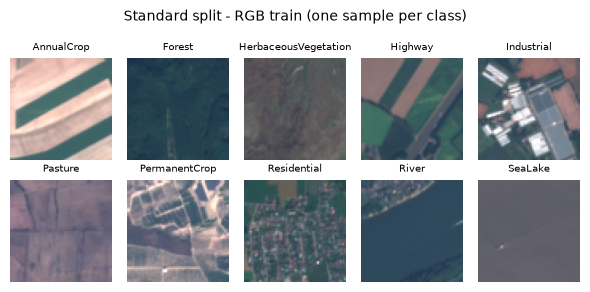

In [5]:
show_RGB(rgb_train_std, "Standard split - RGB train (one sample per class)")

# 2. Spatial Split

## 2.1 13 Bands Multispectral Dataset

In [6]:
# Create MS train/test datasets (using spatial splits)
ms_train_ss = EuroSATDataset(modality='ms', split_type='spatial', split='train')
ms_test_ss = EuroSATDataset(modality='ms', split_type='spatial', split='test')

print(f"Multispectral Train set size: {len(ms_train_ss)}")
print(f"Multispectral Test set size: {len(ms_test_ss)}")

# Fetch a single sample
ms_img, ms_label = ms_train_ss[0]
print(f"Image shape: {ms_img.shape}")
print(f"Label ID: {ms_label} ({CLASS_NAMES[ms_label]})")

Multispectral Train set size: 16200
Multispectral Test set size: 5400
Image shape: torch.Size([13, 64, 64])
Label ID: 6 (PermanentCrop)


In [7]:
# Create DataLoader
train_loader = DataLoader(ms_train_ss, batch_size=32, shuffle=True, num_workers=2)

# Fetch one batch
for imgs, labels in train_loader:
    print("Batch loaded successfully!")
    print("Batch images shape:", imgs.shape)
    print("Batch labels shape:", labels.shape)
    break

Batch loaded successfully!
Batch images shape: torch.Size([32, 13, 64, 64])
Batch labels shape: torch.Size([32])


## 2.2. RGB Datasets

In [8]:
rgb_train_ss = EuroSATDataset(modality='rgb', split_type='spatial', split='train')
rgb_test_ss = EuroSATDataset(modality='rgb', split_type='spatial', split='test')

print(f"RGB Train set size: {len(rgb_train_ss)}")
print(f"RGB Test set size: {len(rgb_test_ss)}")

# Fetch a single sample
rgb_img, rgb_label = rgb_train_ss[0]
print(f"Image shape: {rgb_img.shape}")
print(f"Label ID: {rgb_label} ({CLASS_NAMES[rgb_label]})")

RGB Train set size: 16200
RGB Test set size: 5400
Image shape: torch.Size([3, 64, 64])
Label ID: 6 (PermanentCrop)


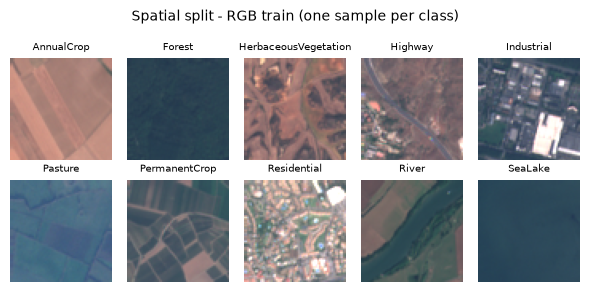

In [9]:
show_RGB(rgb_train_ss, "Spatial split - RGB train (one sample per class)")

# 3. Training Pipeline

This section documents the reusable ResNet-50 model factory and config-driven training engine added for W1-C. The implementation lives in `src/satx/models/` and `src/satx/engine/`; this notebook is only a lightweight usage note and smoke-test guide.

PyTorch, torchvision, and TorchGeo are intentionally not pinned here because each teammate may need a device-specific install (CUDA, MPS, or CPU). If those packages are missing, the smoke-test cell below will skip model construction instead of failing the whole notebook.

## 3.1 Training configuration examples

The next cells show how to create W1-C training configs directly in Python and how to load equivalent reusable YAML configs from `configs/`.

In [4]:
from satx.engine import TrainingConfig, load_training_config

rgb_config = TrainingConfig(
    modality="rgb",
    split_type="spatial",
    epochs=1,
    batch_size=16,
    pretrained=False,
)

ms_config = TrainingConfig(
    modality="ms",
    split_type="spatial",
    model_input_mode="direct",
    epochs=1,
    batch_size=16,
    pretrained=True,
)

print(rgb_config)
print(ms_config)

TrainingConfig(modality='rgb', split_type='spatial', data_dir='./data', splits_dir='./splits_data', output_dir='./outputs/runs', model_input_mode='direct', num_classes=10, pretrained=False, epochs=1, batch_size=16, num_workers=0, learning_rate=0.001, weight_decay=0.0001, seed=42, device='auto', pin_memory=True)
TrainingConfig(modality='ms', split_type='spatial', data_dir='./data', splits_dir='./splits_data', output_dir='./outputs/runs', model_input_mode='direct', num_classes=10, pretrained=True, epochs=1, batch_size=16, num_workers=0, learning_rate=0.001, weight_decay=0.0001, seed=42, device='auto', pin_memory=True)


In [5]:
# The same settings can be loaded from reusable config files.
# Support running the notebook from either the project root or notebooks/.
from pathlib import Path

config_dir = Path("configs") if Path("configs").exists() else Path("../configs")
loaded_rgb_config = load_training_config(config_dir / "rgb_spatial.yaml")
loaded_ms_config = load_training_config(config_dir / "ms_spatial.yaml")

print(loaded_rgb_config.run_name)
print(loaded_ms_config.run_name)

resnet50_rgb_spatial_direct_scratch_seed42
resnet50_ms_spatial_direct_scratch_seed42


## 3.2 Model construction smoke test

This lightweight check builds RGB and multispectral ResNet-50 models and runs dummy tensors through them. It verifies model construction and output shapes without reading data or training weights.


In [7]:
# Model construction smoke test.
# This is safe to run only after installing torch and torchvision for your device.
try:
    import torch
    from satx.models import build_resnet50
except ImportError as exc:
    print(f"Skipping model smoke test: {exc}")
else:
    ms_model = build_resnet50(
        in_channels=ms_config.in_channels,
        num_classes=ms_config.num_classes,
        pretrained=ms_config.pretrained,
        input_mode=ms_config.model_input_mode,
    )

    ms_model.eval()
    with torch.no_grad():
        ms_logits = ms_model(torch.zeros(2, 13, 64, 64))

    print("MS logits shape:", tuple(ms_logits.shape))

MS logits shape: (2, 10)


## 3.3 Optional local training and evaluation smoke tests

Run these only after EuroSAT_MS is available under `../data/EuroSAT_MS` and the device-specific PyTorch/TorchGeo stack is installed. Step 1 runs a one-epoch W1-C training smoke test and stores the returned `history`. Step 2 reuses that `history` to exercise the W1-D evaluation artifact and plotting helpers. Set the smoke-test flags intentionally so restarting the shared notebook does not accidentally launch training or write evaluation outputs.

### 3.3.1 Step 1: W1-C training smoke test


In [10]:
RUN_TRAINING_SMOKE_TEST = True

if RUN_TRAINING_SMOKE_TEST:
    from satx.engine import fit

    smoke_config = TrainingConfig(
        modality="rgb",
        split_type="spatial",
        epochs=1,
        batch_size=16,
        pretrained=False,
    )

    history = fit(smoke_config)

    print("Training smoke test completed.")
    print("best_epoch:", history["best_epoch"])
    print("best_val_accuracy:", history["best_val_accuracy"])
    print("num_epochs:", len(history["epochs"]))
    print("run_dir:", smoke_config.run_dir())
else:
    print(
        "Set RUN_TRAINING_SMOKE_TEST = True after installing dependencies "
        "and downloading EuroSAT_MS."
    )


/Users/ql/Documents/OMSCS/CS_7643/Homework/Final_Project/satx-eurosat-geographic-generalization-study/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training smoke test completed.
best_epoch: 1
best_val_accuracy: 0.2301851851851852
num_epochs: 1
run_dir: /Users/ql/Documents/OMSCS/CS_7643/Homework/Final_Project/satx-eurosat-geographic-generalization-study/outputs/runs/resnet50_rgb_spatial_direct_scratch_seed42


### 3.3.2 Step 2: W1-D evaluation smoke test

Run this after Step 1 has produced `history`. It uses the final validation epoch's `y_true` and `y_pred` values, so it can be rerun without repeating training as long as `history` is still available in the notebook kernel.


In [12]:
RUN_EVALUATION_SMOKE_TEST = True

if RUN_EVALUATION_SMOKE_TEST:

    from satx.eval import (
        generate_evaluation_artifact,
        plot_evaluation_results,
        print_evaluation_results,
    )

    output_dir = smoke_config.evaluation_dir("validation")
    output_dir.mkdir(parents=True, exist_ok=True)

    last_val = history["epochs"][-1]["val"]
    y_true = last_val["y_true"]
    y_pred = last_val["y_pred"]

    artifact = generate_evaluation_artifact(
        y_true,
        y_pred,
        output_path=str(output_dir / "evaluation_artifact.json"),
    )

    print_evaluation_results(artifact)
    plot_evaluation_results(artifact, output_dir=str(output_dir))
else:
    print("Set RUN_EVALUATION_SMOKE_TEST = True after training history is available.")


Evaluation artifact successfully saved to: /Users/ql/Documents/OMSCS/CS_7643/Homework/Final_Project/satx-eurosat-geographic-generalization-study/outputs/runs/resnet50_rgb_spatial_direct_scratch_seed42/evaluation/validation/evaluation_artifact.json

EVALUATION RESULTS SUMMARY
Overall Accuracy : 0.2302
Macro F1 Score   : 0.1340
-------------------------------------------------------
Per-Class F1 Scores:
  - AnnualCrop               : 0.1451
  - Forest                   : 0.3308
  - HerbaceousVegetation     : 0.0000
  - Highway                  : 0.0227
  - Industrial               : 0.5228
  - Pasture                  : 0.0100
  - PermanentCrop            : 0.0000
  - Residential              : 0.0000
  - River                    : 0.0058
  - SeaLake                  : 0.3032

Visualizations successfully saved to: /Users/ql/Documents/OMSCS/CS_7643/Homework/Final_Project/satx-eurosat-geographic-generalization-study/outputs/runs/resnet50_rgb_spatial_direct_scratch_seed42/evaluation/validat

## 3.4 Training on 13 bands (MS), spatial split

Screen all 3 x 3 = 9 combinations at `SCREEN_EPOCHS = 5`, then train the winning
`(lr, wd)` at full length in the final run below.

Searched:

| axis | values |
|---|---|
| `learning_rate` | 1e-4, 3e-4, 1e-3 | 
| `weight_decay` | 1e-5, 1e-4, 1e-3 | 

Held fixed: `model_input_mode="direct"`, `pretrained=True`, `batch_size=32`, `seed=42`.

Ranked on macro-F1.

In [ ]:
import itertools
import json
import time

from sklearn.metrics import accuracy_score, f1_score

from satx.engine import TrainingConfig, fit
from satx.utils.paths import resolve_project_path

SCREEN_EPOCHS = 5
LEARNING_RATES = [1e-4, 3e-4, 1e-3]
WEIGHT_DECAYS = [1e-5, 1e-4, 1e-3]

summary_path = resolve_project_path("outputs/grid/ms_spatial/screen_summary.json")

if summary_path.exists():
    results = json.loads(summary_path.read_text())
else:
    results = []
    for lr, wd in itertools.product(LEARNING_RATES, WEIGHT_DECAYS):
        tag = f"lr{lr:g}_wd{wd:g}"

        config = TrainingConfig(
            modality="ms",
            split_type="spatial",
            model_input_mode="direct",
            pretrained=True,
            epochs=SCREEN_EPOCHS,
            batch_size=32,
            num_workers=4,
            pin_memory=False,
            learning_rate=lr,
            weight_decay=wd,
            seed=42,
            output_dir=f"./outputs/grid/ms_spatial/{tag}",
        )

        started = time.time()
        history = fit(config)

        final_val = history["epochs"][-1]["val"]
        y_true, y_pred = final_val["y_true"], final_val["y_pred"]

        results.append(
            {
                "learning_rate": lr,
                "weight_decay": wd,
                "epochs": SCREEN_EPOCHS,
                "best_epoch": history["best_epoch"],
                "best_val_accuracy": history["best_val_accuracy"],
                "final_accuracy": accuracy_score(y_true, y_pred),
                "final_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
                "minutes": round((time.time() - started) / 60, 1),
            }
        )

    summary_path.parent.mkdir(parents=True, exist_ok=True)
    summary_path.write_text(json.dumps(results, indent=2))

for r in results:
    tag = f"lr{r['learning_rate']:g}_wd{r['weight_decay']:g}"
    print(f"{tag:20s} macro_f1={r['final_macro_f1']:.4f}  "
          f"acc={r['final_accuracy']:.4f}  ({r['minutes']:.1f} min)")

lookup = {(r["learning_rate"], r["weight_decay"]): r["final_macro_f1"] for r in results}
print(f"\nmacro-F1 @ epoch {results[0]['epochs']}")
print("lr \\ wd    " + "".join(f"{wd:<10g}" for wd in WEIGHT_DECAYS))
for lr in LEARNING_RATES:
    print(f"{lr:<10g} " + "".join(f"{lookup[(lr, wd)]:<10.4f}" for wd in WEIGHT_DECAYS))

best = max(results, key=lambda r: r["final_macro_f1"])
print(f"\nBest by macro-F1: lr={best['learning_rate']:g}, wd={best['weight_decay']:g} "
      f"-> F1={best['final_macro_f1']:.4f} (acc={best['final_accuracy']:.4f})")

lr0.0001_wd1e-05     macro_f1=0.9275  acc=0.9511  (3.9 min)
lr0.0001_wd0.0001    macro_f1=0.9275  acc=0.9511  (3.8 min)
lr0.0001_wd0.001     macro_f1=0.9362  acc=0.9576  (3.8 min)
lr0.0003_wd1e-05     macro_f1=0.8978  acc=0.9344  (3.8 min)
lr0.0003_wd0.0001    macro_f1=0.9199  acc=0.9476  (3.8 min)
lr0.0003_wd0.001     macro_f1=0.8986  acc=0.9374  (3.8 min)
lr0.001_wd1e-05      macro_f1=0.8734  acc=0.9030  (3.8 min)
lr0.001_wd0.0001     macro_f1=0.8696  acc=0.9113  (3.8 min)
lr0.001_wd0.001      macro_f1=0.8455  acc=0.8913  (3.8 min)

macro-F1 @ epoch 5
lr \ wd    1e-05     0.0001    0.001     
0.0001     0.9275    0.9275    0.9362    
0.0003     0.8978    0.9199    0.8986    
0.001      0.8734    0.8696    0.8455    

Best by macro-F1: lr=0.0001, wd=0.001 -> F1=0.9362 (acc=0.9576)


In [21]:
from sklearn.metrics import accuracy_score, f1_score
from satx.engine import TrainingConfig, fit

final_config = TrainingConfig(
    modality="ms",
    split_type="spatial",
    model_input_mode="direct",
    pretrained=True,
    epochs=10,
    batch_size=32,
    num_workers=4,
    learning_rate=1e-4,
    weight_decay=1e-3,
    seed=42,
)

In [ ]:
final_history = fit(final_config)

best_epoch = final_history['best_epoch'] - 1
final_val = final_history["epochs"][best_epoch]["val"]
print(f"macro-F1   : {final_val['macro_f1']:.4f}")
print(f"accuracy   : {final_val['accuracy']:.4f}")
print(f"best epoch : {final_history['best_epoch']} / {final_config.epochs}")
print(f"run_dir    : {final_config.run_dir()}")

NameError: name 'final_history' is not defined

# 4. Noise robustness (MS, spatial split)

| | Description | scaling |
|---|---|---|
| **Gaussian** | additive `N(0, sigma)`, signal-independent | `sigma` in units of each band's std |
| **Shot (Poisson)** | `Poisson(x/g)*g`, variance tracks the signal | self-scaling; relative noise is `sqrt(g/x)` |

- **4.1 phase 1** - the clean-trained model evaluated across noise levels. Inference only,
- **4.2 phase 2** - retraining *with* noise, which does require one model per level.

## 4.1 Phase 1 - clean-trained model vs noise levels

In [23]:
import torch

from satx.data.noise import build_noise, perturbation_ratio

MODALITY, SPLIT_TYPE = "ms", "spatial"

NOISE_SETTINGS = (
    [("none", 0.0)]
    + [("gaussian", s) for s in (0.005, 0.01, 0.02, 0.05, 0.1, 0.25)]
    + [("shot", g) for g in (0.01, 0.1, 1.0, 5.0, 10.0)]
)

print(f"{'setting':<18}{'mean|dx| / mean|x|':>20}")
for kind, level in NOISE_SETTINGS:
    label = "clean" if kind == "none" else f"{kind} {level:g}"
    print(f"{label:<18}{perturbation_ratio(kind, level, MODALITY, SPLIT_TYPE):>19.4%}")

setting             mean|dx| / mean|x|
clean                         0.0000%
gaussian 0.005                0.1433%
gaussian 0.01                 0.2865%
gaussian 0.02                 0.5731%
gaussian 0.05                 1.4327%
gaussian 0.1                  2.8655%
gaussian 0.25                 7.1637%
shot 0.01                     0.1779%
shot 0.1                      0.5625%
shot 1                        1.7789%
shot 5                        3.9803%
shot 10                       5.6298%


In [24]:
RUN_PHASE1 = True

import json

from satx.eval.noise import sweep_noise
from satx.utils.paths import resolve_project_path

BASELINE_RUN = resolve_project_path(
    "outputs/runs/resnet50_ms_spatial_direct_pretrained_seed42"
)

phase1_path = resolve_project_path("outputs/noise/ms_spatial/phase1_clean_trained.json")

if RUN_PHASE1:
    phase1 = sweep_noise(BASELINE_RUN, NOISE_SETTINGS)
    phase1_path.parent.mkdir(parents=True, exist_ok=True)
    phase1_path.write_text(json.dumps(phase1, indent=2))
elif phase1_path.exists():
    phase1 = json.loads(phase1_path.read_text())
else:
    phase1 = []
    print("Set RUN_PHASE1 = True to sweep the baseline across noise levels.")

clean              macro_f1=0.9291  acc=0.9513
gaussian 0.005     macro_f1=0.9319  acc=0.9530
gaussian 0.01      macro_f1=0.9351  acc=0.9544
gaussian 0.02      macro_f1=0.9065  acc=0.9143
gaussian 0.05      macro_f1=0.8525  acc=0.9056
gaussian 0.1       macro_f1=0.6152  acc=0.6589
gaussian 0.25      macro_f1=0.2372  acc=0.3309
shot 0.01          macro_f1=0.9339  acc=0.9539
shot 0.1           macro_f1=0.9315  acc=0.9511
shot 1             macro_f1=0.7991  acc=0.8400
shot 5             macro_f1=0.5999  acc=0.7144
shot 10            macro_f1=0.4224  acc=0.5413


## 4.2 Phase 2 - training with noise
- **Only the training set is corrupted.** Validation stays clean.

In [25]:
RUN_PHASE2 = True
TRAIN_NOISE_LEVELS = [("gaussian", 0.05), ("gaussian", 0.1), ("shot", 0.1), ("shot", 1)]

from dataclasses import replace

from satx.engine import fit_noisy

phase2_path = resolve_project_path("outputs/noise/ms_spatial/phase2_noisy_trained.json")

if RUN_PHASE2:
    phase2 = []
    for kind, level in TRAIN_NOISE_LEVELS:
        noisy_config = replace(
            final_config,
            num_workers=4,
            pin_memory=False,
            output_dir=f"./outputs/noise/train/{kind}{level:g}",
        )
        print(f"\n=== training with {kind} {level:g} ===")
        history = fit_noisy(noisy_config, kind, level)
        print(f"--- sweeping the {kind} {level:g} model across all noise levels ---")
        phase2.append(
            {
                "train_noise": kind,
                "train_level": level,
                "best_epoch": history["best_epoch"],
                "clean_val_macro_f1": history["best_val_macro_f1"],
                "curve": sweep_noise(noisy_config.run_dir(), NOISE_SETTINGS),
            }
        )
    phase2_path.parent.mkdir(parents=True, exist_ok=True)
    phase2_path.write_text(json.dumps(phase2, indent=2))
elif phase2_path.exists():
    phase2 = json.loads(phase2_path.read_text())
else:
    phase2 = []
    print("Set RUN_PHASE2 = True to train noise-augmented models.")


=== training with gaussian 0.05 ===
Starting run: resnet50_ms_spatial_direct_pretrained_seed42
Device: mps
Epochs: 10
Batch size: 32

Epoch 01/10
  train loss=0.4667 acc=0.8606
  val   loss=0.3600 acc=0.8922 macro_f1=0.8519
  best val macro_f1=0.8519

Epoch 02/10
  train loss=0.1118 acc=0.9661
  val   loss=0.8646 acc=0.8020 macro_f1=0.7939
  best val macro_f1=0.8519

Epoch 03/10
  train loss=0.0640 acc=0.9797
  val   loss=0.6014 acc=0.8267 macro_f1=0.8226
  best val macro_f1=0.8519

Epoch 04/10
  train loss=0.0443 acc=0.9867
  val   loss=0.4201 acc=0.8381 macro_f1=0.8351
  best val macro_f1=0.8519

Epoch 05/10
  train loss=0.0369 acc=0.9888
  val   loss=0.3203 acc=0.9080 macro_f1=0.8642
  best val macro_f1=0.8642

Epoch 06/10
  train loss=0.0276 acc=0.9913
  val   loss=0.2198 acc=0.9307 macro_f1=0.8991
  best val macro_f1=0.8991

Epoch 07/10
  train loss=0.0249 acc=0.9919
  val   loss=0.2736 acc=0.9241 macro_f1=0.8956
  best val macro_f1=0.8991

Epoch 08/10
  train loss=0.0240 acc=0.9

model               noise             pert  macro_f1      acc    rel
clean-trained       clean            0.0%    0.9291   0.9513  1.000
clean-trained       gaussian 0.005   0.1%    0.9319   0.9530  1.003
clean-trained       gaussian 0.01    0.3%    0.9351   0.9544  1.007
clean-trained       gaussian 0.02    0.6%    0.9065   0.9143  0.976
clean-trained       gaussian 0.05    1.4%    0.8525   0.9056  0.918
clean-trained       gaussian 0.1     2.9%    0.6152   0.6589  0.662
clean-trained       gaussian 0.25    7.2%    0.2372   0.3309  0.255
clean-trained       shot 0.01        0.2%    0.9339   0.9539  1.005
clean-trained       shot 0.1         0.6%    0.9315   0.9511  1.003
clean-trained       shot 1           1.8%    0.7991   0.8400  0.860
clean-trained       shot 5           4.0%    0.5999   0.7144  0.646
clean-trained       shot 10          5.6%    0.4224   0.5413  0.455
trained gauss 0.05  clean            0.0%    0.9094   0.9417  0.979
trained gauss 0.05  gaussian 0.005   0.1%    0.

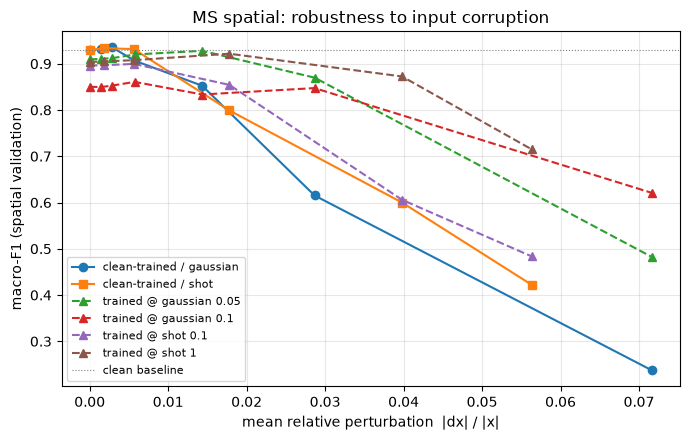

In [26]:
if not phase1:
    print("Run 4.1 first.")
else:
    import matplotlib.pyplot as plt

    clean_f1 = next(r["macro_f1"] for r in phase1 if r["noise"] == "none")

    print(f"{'model':<20}{'noise':<14}{'pert':>8}{'macro_f1':>10}{'acc':>9}{'rel':>7}")
    for row in phase1:
        label = "clean" if row["noise"] == "none" else f"{row['noise']} {row['level']:g}"
        print(f"{'clean-trained':<20}{label:<14}{row['perturbation']:>7.1%}"
              f"{row['macro_f1']:>10.4f}{row['accuracy']:>9.4f}"
              f"{row['macro_f1'] / clean_f1:>7.3f}")
    for entry in phase2:
        name = f"trained {entry['train_noise'][:5]} {entry['train_level']:g}"
        for row in entry["curve"]:
            label = "clean" if row["noise"] == "none" else f"{row['noise']} {row['level']:g}"
            print(f"{name:<20}{label:<14}{row['perturbation']:>7.1%}"
                  f"{row['macro_f1']:>10.4f}{row['accuracy']:>9.4f}"
                  f"{row['macro_f1'] / clean_f1:>7.3f}")

    def curve(rows, kind):
        points = sorted(
            (r for r in rows if r["noise"] in ("none", kind)),
            key=lambda r: r["perturbation"],
        )
        return [r["perturbation"] for r in points], [r["macro_f1"] for r in points]

    figure, axes = plt.subplots(figsize=(7, 4.5))
    for kind, marker in (("gaussian", "-o"), ("shot", "-s")):
        x, y = curve(phase1, kind)
        axes.plot(x, y, marker, label=f"clean-trained / {kind}")
    for entry in phase2:
        x, y = curve(entry["curve"], entry["train_noise"])
        axes.plot(x, y, "--^", label=f"trained @ {entry['train_noise']} {entry['train_level']:g}")

    axes.axhline(clean_f1, color="grey", lw=0.8, ls=":", label="clean baseline")
    axes.set_xlabel("mean relative perturbation  |dx| / |x|")
    axes.set_ylabel("macro-F1 (spatial validation)")
    axes.set_title("MS spatial: robustness to input corruption")
    axes.legend(fontsize=8)
    axes.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()